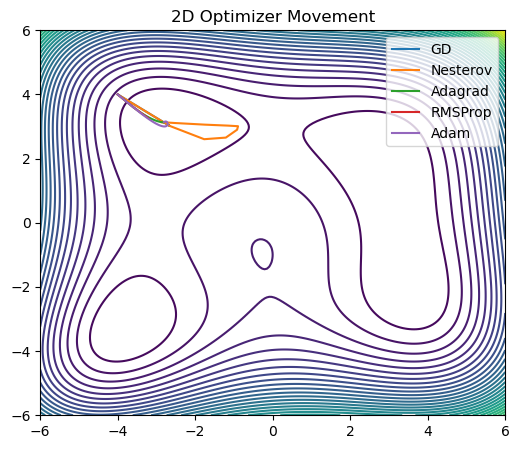

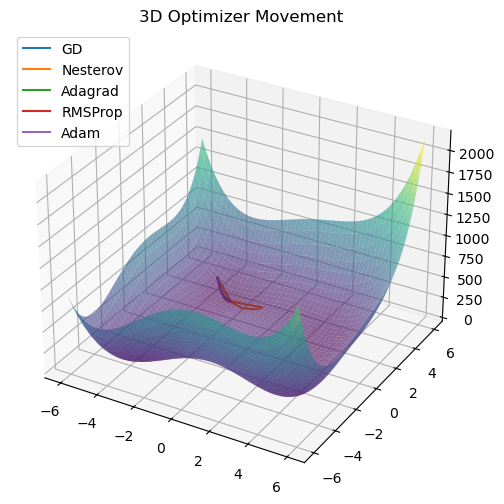

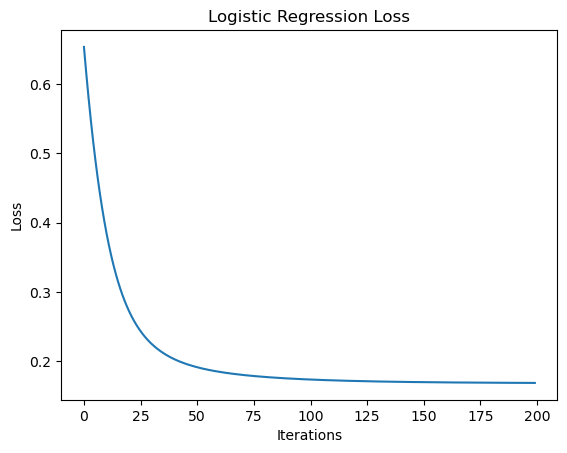

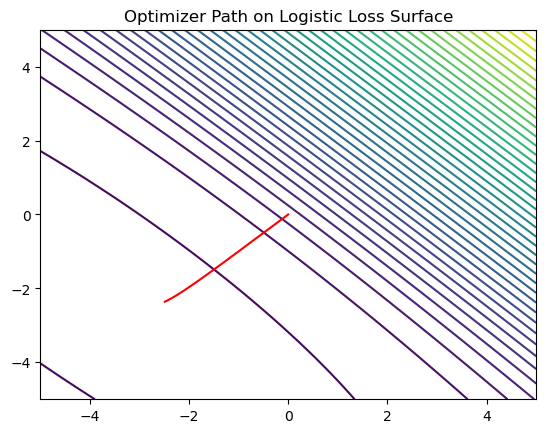

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation, cm
from IPython.display import HTML
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# Himmelblau function
def himmelblau_loss(w):
    x, y = w
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

# Gradient of Himmelblau
def himmelblau_grad(w):
    x, y = w
    dx = 4*x*(x**2 + y - 11) + 2*(x + y**2 - 7)
    dy = 2*(x**2 + y - 11) + 4*y*(x + y**2 - 7)
    return np.array([dx, dy])

# Optimizers
def step_gd(w, lr):
    return w - lr * himmelblau_grad(w)

def step_nesterov(w, v, lr, gamma=0.9):
    look = w - gamma * v
    g = himmelblau_grad(look)
    v = gamma*v + lr*g
    return w - v, v

def step_adagrad(w, G, lr):
    g = himmelblau_grad(w)
    G += g**2
    w -= lr * g / (np.sqrt(G)+1e-8)
    return w, G

def step_rmsprop(w, Eg, lr, beta=0.9):
    g = himmelblau_grad(w)
    Eg = beta*Eg + (1-beta)*(g**2)
    w -= lr * g / (np.sqrt(Eg)+1e-8)
    return w, Eg

def step_adam(w, m, v, t, lr):
    g = himmelblau_grad(w)

    m = 0.9*m + 0.1*g
    v = 0.999*v + 0.001*(g**2)

    mhat = m/(1-0.9**t)
    vhat = v/(1-0.999**t)

    w -= lr * mhat / (np.sqrt(vhat)+1e-8)
    return w, m, v


# Initial point
start = np.array([-4.0,4.0])
steps = 80
lr = 0.01

paths = {}

# Gradient Descent
w=start.copy()
p=[w.copy()]
for i in range(steps):
    w = step_gd(w,lr)
    p.append(w.copy())
paths["GD"] = np.array(p)

# Nesterov
w=start.copy()
v=np.zeros(2)
p=[w.copy()]
for i in range(steps):
    w,v = step_nesterov(w,v,lr)
    p.append(w.copy())
paths["Nesterov"] = np.array(p)

# Adagrad
w=start.copy()
G=np.zeros(2)
p=[w.copy()]
for i in range(steps):
    w,G = step_adagrad(w,G,0.4)
    p.append(w.copy())
paths["Adagrad"] = np.array(p)

# RMSProp
w=start.copy()
Eg=np.zeros(2)
p=[w.copy()]
for i in range(steps):
    w,Eg = step_rmsprop(w,Eg,lr)
    p.append(w.copy())
paths["RMSProp"] = np.array(p)

# Adam
w=start.copy()
m=np.zeros(2)
v=np.zeros(2)
p=[w.copy()]
for t in range(1,steps+1):
    w,m,v = step_adam(w,m,v,t,0.05)
    p.append(w.copy())
paths["Adam"] = np.array(p)


# Himmelblau surface grid
x = np.linspace(-6,6,200)
y = np.linspace(-6,6,200)

X,Y = np.meshgrid(x,y)
Z = himmelblau_loss([X,Y])


# 2D Contour plot
plt.figure(figsize=(6,5))
plt.contour(X,Y,Z,40)

for name,p in paths.items():
    plt.plot(p[:,0],p[:,1],label=name)

plt.legend()
plt.title("2D Optimizer Movement")
plt.show()


# 3D Surface
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111,projection='3d')

ax.plot_surface(X,Y,Z,cmap=cm.viridis,alpha=0.6)

for name,p in paths.items():
    z=[himmelblau_loss(pt) for pt in p]
    ax.plot(p[:,0],p[:,1],z,label=name)

ax.set_title("3D Optimizer Movement")
plt.legend()
plt.show()


# MNIST dataset
(x_train,y_train),_ = tf.keras.datasets.mnist.load_data()

mask=(y_train==0)|(y_train==1)
x = x_train[mask]
y = y_train[mask]

x = x.reshape(len(x),-1)

f1 = x[:,:392].mean(axis=1)
f2 = x[:,392:].mean(axis=1)

X_lr = np.vstack((f1,f2)).T
X_lr = StandardScaler().fit_transform(X_lr)

y = y.astype(np.float32)


# Logistic Regression helpers
def sigmoid(z):
    return 1/(1+np.exp(-z))

def logistic_loss(w):
    p = sigmoid(X_lr.dot(w))
    return -np.mean(y*np.log(p+1e-8)+(1-y)*np.log(1-p+1e-8))

def logistic_grad(w):
    p = sigmoid(X_lr.dot(w))
    return X_lr.T.dot(p-y)/len(y)


def train_adam_lr(steps=200,lr=0.05):

    w=np.zeros(2)
    m=np.zeros(2)
    v=np.zeros(2)

    b1,b2=0.9,0.999
    eps=1e-8

    path=[w.copy()]
    losses=[]

    for t in range(1,steps+1):

        g = logistic_grad(w)

        m=b1*m+(1-b1)*g
        v=b2*v+(1-b2)*(g**2)

        mhat=m/(1-b1**t)
        vhat=v/(1-b2**t)

        w-=lr*mhat/(np.sqrt(vhat)+eps)

        path.append(w.copy())
        losses.append(logistic_loss(w))

    return np.array(path),losses


path_lr,loss_lr_vals = train_adam_lr()


# Logistic loss curve
plt.plot(loss_lr_vals)
plt.title("Logistic Regression Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()


# Logistic contour
w1=np.linspace(-5,5,100)
w2=np.linspace(-5,5,100)

W1,W2=np.meshgrid(w1,w2)
Z2=np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        Z2[i,j] = logistic_loss(np.array([W1[i,j],W2[i,j]]))

plt.contour(W1,W2,Z2,40)
plt.plot(path_lr[:,0],path_lr[:,1],'r')
plt.title("Optimizer Path on Logistic Loss Surface")
plt.show()